In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import folium

In [3]:
df = pd.read_csv('Desktop/Artificial Intelligence/Connecticut Weather_Stations.csv')

In [4]:
df.head()

,Station,Longitude,Latitude
0,Bridgeport Sikorsky Mem Airport,-73.1270,41.1640
1,Bulls Bridge Dam,-73.4830,41.6500
2,Burlington,-72.9700,41.7700
3,Cockaponset Rs,-72.5197,41.4614
4,Coventry,-72.3100,41.7700


In [5]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitude '], df['Latitude ']),
    crs="EPSG:4326"  # Standard WGS84 coordinate reference system
)
gdf.head()

,Station,Longitude,Latitude,geometry
0,Bridgeport Sikorsky Mem Airport,-73.1270,41.1640,POINT (-73.127 41.164)
1,Bulls Bridge Dam,-73.4830,41.6500,POINT (-73.483 41.65)
2,Burlington,-72.9700,41.7700,POINT (-72.97 41.77)
3,Cockaponset Rs,-72.5197,41.4614,POINT (-72.5197 41.4614)
4,Coventry,-72.3100,41.7700,POINT (-72.31 41.77)


In [6]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# Reads the data
CT = gpd.read_file('Desktop/Artificial Intelligence/Connecticut_Routes_-8583715507025981790/deepgis_DEEP_ROUTES.shp')

In [8]:
# Explores Connecticut route data
CT.head(50)

,ROUTE,ROUTECLASS,ROUTENO,ROUTENAME,SCALELEVEL,geometry
0,Bradley International Airport Connector,Connector,None,Bradley International Airport Connector,6,"LINESTRING (1014834.438 896835.938, 1014794.87..."
1,Route 6 Connector,Connector,None,Route 6 Connector,6,"MULTILINESTRING ((1239317.5 840426.688, 123952..."
2,Route 9 Connector,Connector,None,Route 9 Connector,6,"LINESTRING (988728.125 796693.625, 988892.125 ..."
3,Montville Connector,Connector,None,Montville Connector,6,"MULTILINESTRING ((1171659 718023.75, 1171631.5..."
4,Wharton Brook Connector,Connector,None,Wharton Brook Connector,6,"MULTILINESTRING ((976349.438 717304.125, 97684..."
5,Rocky Neck Connector,Connector,None,Rocky Neck Connector,6,"LINESTRING (1137409.625 679686.438, 1137797.37..."
6,Hammonasset Connector,Connector,None,Hammonasset Connector,6,"LINESTRING (1049401.875 666660.5, 1049512.25 6..."
7,Milford Parkway,Connector,None,Milford Parkway,6,"MULTILINESTRING ((909399.125 652663.125, 90950..."
8,Sherwood Island Connector,Connector,None,Sherwood Island Connector,6,"LINESTRING (838510.688 611590.938, 838725.375 ..."
9,Branford Connector,Connector,None,Branford Connector,6,"LINESTRING (976214.875 664871.75, 976516.188 6..."


In [9]:
# prints data on rows 64 and 153
print(CT.iloc[[64,153]])

               ROUTE   ROUTECLASS ROUTENO ROUTENAME  SCALELEVEL  \
64   State Route 341  State Route     341      None           5   
153   State Route 59  State Route      59      None           5   

                                              geometry  
64   LINESTRING (792285.875 836218.75, 792489.813 8...  
153  LINESTRING (858413.813 678653.563, 857198.063 ...  


<Axes: >

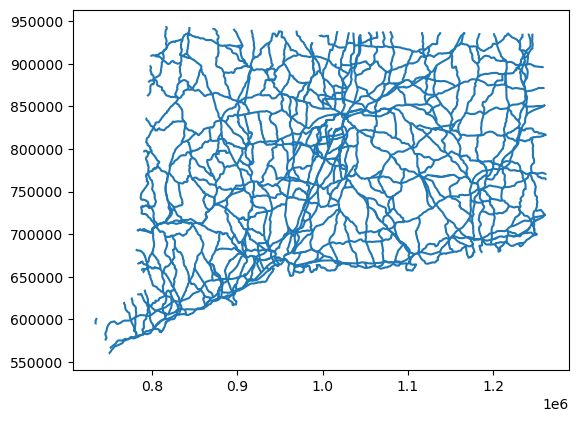

In [10]:
# plots all routes in the state of Connecticut
CT.plot()

<Axes: >

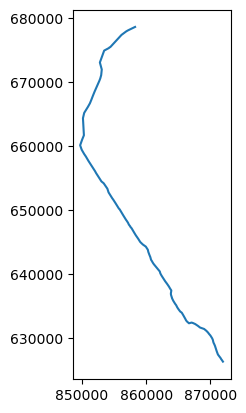

In [11]:
# plots Route 59
(CT[CT['ROUTENO']=='59']).plot()

In [12]:
(CT[CT['ROUTENO']=='59']).geometry

153    LINESTRING (858413.813 678653.563, 857198.063 ...
Name: geometry, dtype: geometry

In [13]:
print(CT[CT['ROUTENO']=='59'])

              ROUTE   ROUTECLASS ROUTENO ROUTENAME  SCALELEVEL  \
153  State Route 59  State Route      59      None           5   

                                              geometry  
153  LINESTRING (858413.813 678653.563, 857198.063 ...  


In [14]:
print(CT[CT['ROUTENO']=='341'])

              ROUTE   ROUTECLASS ROUTENO ROUTENAME  SCALELEVEL  \
64  State Route 341  State Route     341      None           5   

                                             geometry  
64  LINESTRING (792285.875 836218.75, 792489.813 8...  


<Axes: >

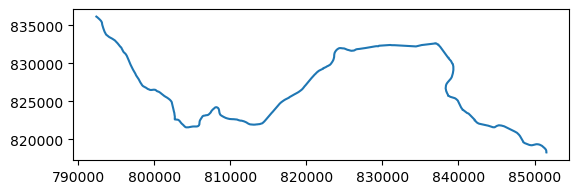

In [15]:
# plots Route 341
(CT[CT['ROUTENO']=='341']).plot()

In [16]:
(CT[CT['ROUTENO']=='59']).crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [17]:
CT.geometry[:5]

0    LINESTRING (1014834.438 896835.938, 1014794.87...
1    MULTILINESTRING ((1239317.5 840426.688, 123952...
2    LINESTRING (988728.125 796693.625, 988892.125 ...
3    MULTILINESTRING ((1171659 718023.75, 1171631.5...
4    MULTILINESTRING ((976349.438 717304.125, 97684...
Name: geometry, dtype: geometry

In [18]:
# Reads state of Connecticut boundary map
CTbnd = gpd.read_file('Desktop/Artificial Intelligence/Connecticut_State_-234834534670141551/Connecticut_Line.shp')

In [19]:
CTbnd.head()

,AV_LEGEND,LENGTH_MI,geometry
0,State Boundary,93.113899,"LINESTRING (297765.812 286099.283, 298651.6 28..."
1,State Boundary,14.278900,"LINESTRING (384777.623 231954.293, 384775.451 ..."
2,State Boundary,115.945999,"LINESTRING (228267.825 170695.961, 228264.396 ..."
3,State Boundary Offshore,105.787003,"LINESTRING (228267.825 170695.961, 228276.073 ..."


In [20]:
CTbnd.geometry

0    LINESTRING (297765.812 286099.283, 298651.6 28...
1    LINESTRING (384777.623 231954.293, 384775.451 ...
2    LINESTRING (228267.825 170695.961, 228264.396 ...
3    LINESTRING (228267.825 170695.961, 228276.073 ...
Name: geometry, dtype: geometry

<Axes: >

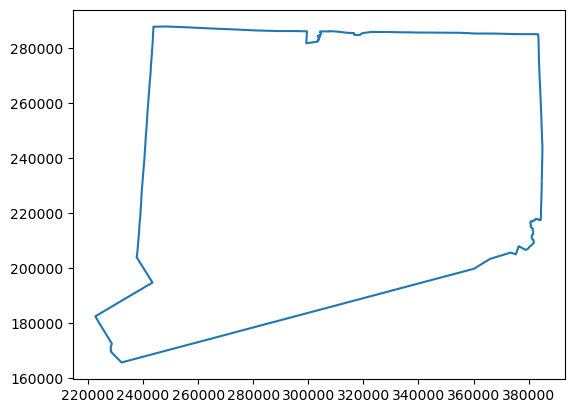

In [21]:
# plots state of Connecticut boundary map
CTbnd.plot()

In [22]:
(CT.iloc[[64,153]]).crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [23]:
(CT[CT['ROUTENO']=='59']).crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [24]:
(CT[CT['ROUTENO']=='341']).crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [25]:
CT.crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [26]:
CTbnd.crs

<Projected CRS: EPSG:26956>
Name: NAD83 / Connecticut
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (meter)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [27]:
CTbnd_projected = CTbnd.to_crs(CT.crs)

In [28]:
CTbnd_projected.crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [29]:
CTbnd_projected.head()

,AV_LEGEND,LENGTH_MI,geometry
0,State Boundary,93.113899,"LINESTRING (976920 938644.063, 979826.125 9385..."
1,State Boundary,14.278900,"LINESTRING (1262391.25 761003.375, 1262384.125..."
2,State Boundary,115.945999,"LINESTRING (748908.688 560025, 748897.438 5600..."
3,State Boundary Offshore,105.787003,"LINESTRING (748908.688 560025, 748935.75 55991..."


In [30]:
CTbnd_projected.geometry

0    LINESTRING (976920 938644.063, 979826.125 9385...
1    LINESTRING (1262391.25 761003.375, 1262384.125...
2    LINESTRING (748908.688 560025, 748897.438 5600...
3    LINESTRING (748908.688 560025, 748935.75 55991...
Name: geometry, dtype: geometry

In [31]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [32]:
gdf_projected = gdf.to_crs(CT.crs)

In [33]:
gdf_projected.crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [34]:
gdf_projected.columns

Index(['Station', 'Longitude ', 'Latitude ', 'geometry'], dtype='object')

<Axes: >

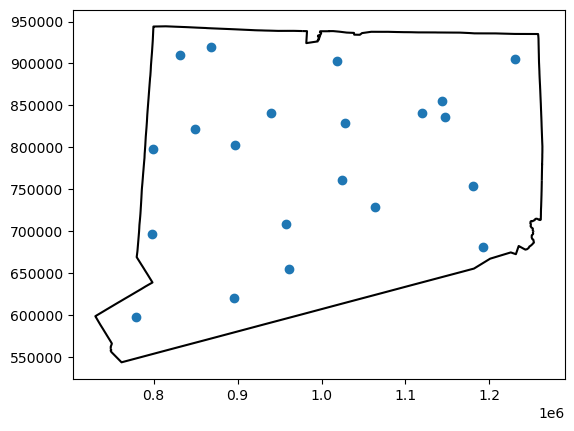

In [35]:
# plots all state of Connecticut Weather Stations in Connecticut boundary map
fig, ax = plt.subplots()
gdf_projected.plot(ax=ax)
CTbnd_projected.plot(ax=ax, color='black')

<Axes: >

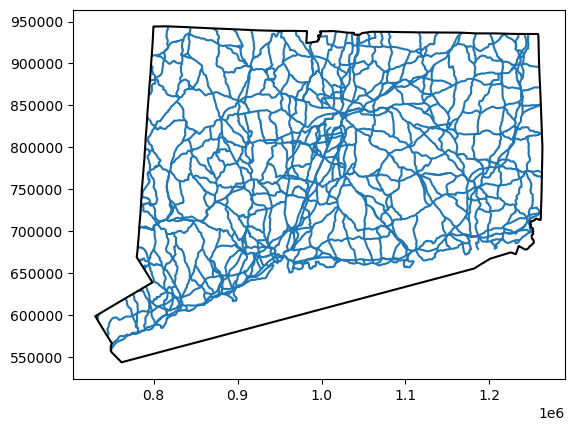

In [36]:
# plots state of Connecticut boundary map and all routes of Connecticut on the same axis
fig, ax = plt.subplots()
CT.plot(ax=ax) 
CTbnd_projected.plot(ax=ax, color='black')

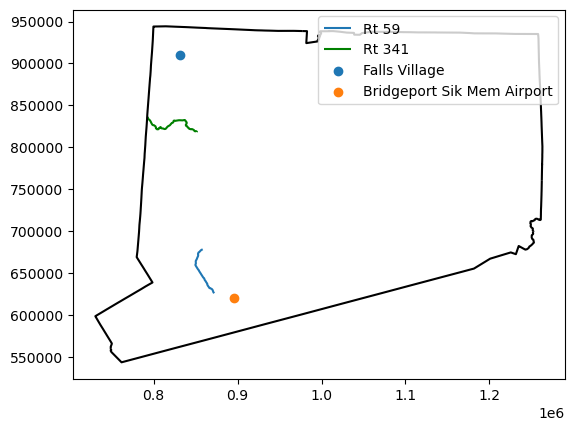

In [37]:
# plots state of Connecticut boundary map, Route 59 and Route 341 on the same axis
fig, ax = plt.subplots()
(CT[CT['ROUTENO']=='59']).plot(ax=ax, label='Rt 59') 
(CT[CT['ROUTENO']=='341']).plot(ax=ax, color='green', label='Rt 341')
(gdf_projected[gdf_projected['Station']=='Falls Village']).plot(ax=ax, label='Falls Village')
(gdf_projected[gdf_projected['Station']=='Bridgeport Sikorsky Mem Airport']).plot(ax=ax, label='Bridgeport Sik Mem Airport' )
CTbnd_projected.plot(ax=ax, color='black')
plt.legend()
# Falls Village in the northern part of Connecticut is a Cold Station
# Bridgeport Sikorsly Memorial Airport in the southern part of Connecticut is a Warm Station

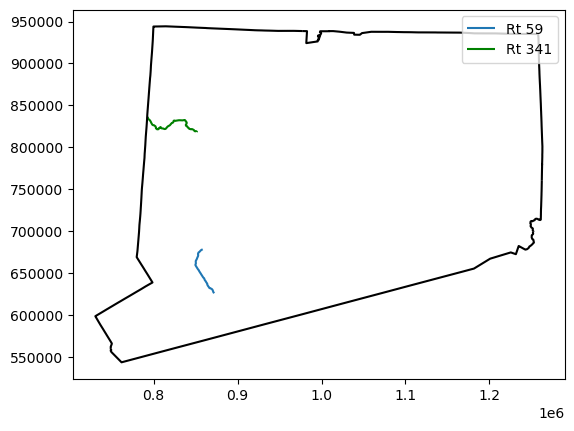

In [38]:
# plots state of Connecticut boundary map, Route 59 and Route 341 on the same axis
fig, ax = plt.subplots()
(CT[CT['ROUTENO']=='59']).plot(ax=ax, label='Rt 59') 
(CT[CT['ROUTENO']=='341']).plot(ax=ax, color='green', label='Rt 341')
CTbnd_projected.plot(ax=ax, color='black')
plt.legend()
